<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/KNN_EX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

In [2]:
digits.data.shape

(1797, 64)

In [4]:
df = pd.DataFrame(digits.data)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [6]:
df = pd.DataFrame(digits.data)

In [7]:
df['target'] = digits.target

In [8]:
X = df.drop('target', axis=1)
y = df['target']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
scores = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    scores.append(score)
    print("K =", k, "Score =", score)

K = 1 Score = 0.9777777777777777
K = 2 Score = 0.9805555555555555
K = 3 Score = 0.9833333333333333
K = 4 Score = 0.9805555555555555
K = 5 Score = 0.9861111111111112
K = 6 Score = 0.9888888888888889
K = 7 Score = 0.9888888888888889
K = 8 Score = 0.9861111111111112
K = 9 Score = 0.9805555555555555
K = 10 Score = 0.9833333333333333
K = 11 Score = 0.9833333333333333
K = 12 Score = 0.9777777777777777
K = 13 Score = 0.9777777777777777
K = 14 Score = 0.9805555555555555
K = 15 Score = 0.9777777777777777
K = 16 Score = 0.9805555555555555
K = 17 Score = 0.9833333333333333
K = 18 Score = 0.9805555555555555
K = 19 Score = 0.975
K = 20 Score = 0.9777777777777777


In [13]:
best_k = scores.index(max(scores)) + 1
print("Best K Value:", best_k)

Best K Value: 6


In [14]:
model = KNeighborsClassifier(n_neighbors=best_k)

In [15]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [16]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9888888888888889


In [20]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  0  1  1  0  0  0 38]]


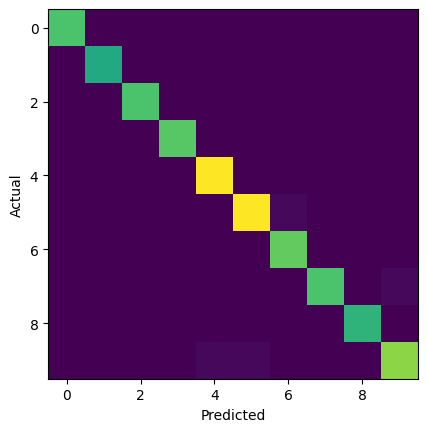

In [22]:
import matplotlib.pyplot as plt
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [24]:
from sklearn.model_selection import GridSearchCV

In [26]:
param_grid = {'n_neighbors': range(1, 21)}

In [27]:
grid = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5)

In [28]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 21)})

In [29]:
print("Best K:", grid.best_params_)

Best K: {'n_neighbors': 1}


In [30]:
print("Best Score:", grid.best_score_)

Best Score: 0.9860820751064654


In [32]:
import joblib
joblib.dump(model, "knn_digits_model.pkl")

['knn_digits_model.pkl']